# SAE feature emergence: findings

Do SAE features emerge **gradually** or via **phase transitions**? We train one SAE per checkpoint, match features across time, and measure **drift** (1 − similarity). We then check **causality** (ablation) and **interpretability** (max-activating examples, feature dynamics). This notebook loads pipeline outputs and states what we find.

**Story:** Setup → Training (loss, checkpoints) → Stability (drift) → Interpretation (H1/H2/H3) → Ablation → Max-activating examples → Feature dynamics → Summary → Further experiments.

## Setup

In [17]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt

ROOT = Path.cwd() if (Path.cwd() / "findings.ipynb").exists() else Path.cwd() / "sae_feature_emergence"
sys.path.insert(0, str(ROOT / "scripts"))
from config import RESULTS_DIR, CHECKPOINTS_DIR
RESULTS_DIR = Path(RESULTS_DIR)
CHECKPOINTS_DIR = Path(CHECKPOINTS_DIR)

## Training (loss and checkpoints)

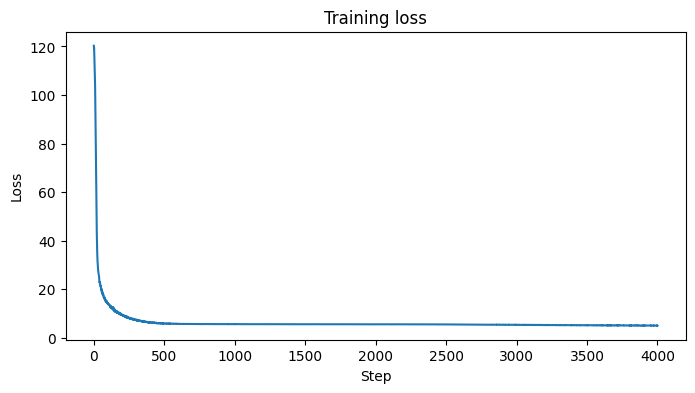

In [18]:
loss_path = RESULTS_DIR / "loss_history.json"
if loss_path.exists():
    with open(loss_path) as f:
        loss_history = json.load(f)
    steps = [x["step"] for x in loss_history]
    losses = [x["loss"] for x in loss_history]
    plt.figure(figsize=(8, 4))
    plt.plot(steps, losses)
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title("Training loss")
    plt.show()
else:
    print("No loss_history.json yet. Run make sae-train.")

### Checkpoints

In [19]:
if CHECKPOINTS_DIR.exists():
    ckpts = sorted(CHECKPOINTS_DIR.glob("step_*.pt"))
    print(f"Checkpoints: {[p.name for p in ckpts]}")
else:
    print("No checkpoints dir yet. Run make sae-train.")

Checkpoints: ['step_100.pt', 'step_1000.pt', 'step_1300.pt', 'step_1600.pt', 'step_200.pt', 'step_2000.pt', 'step_2500.pt', 'step_3000.pt', 'step_3500.pt', 'step_400.pt', 'step_4000.pt', 'step_600.pt', 'step_800.pt']


## Stability (drift)

We use **drift** = 1 − similarity (mean cosine similarity of matched feature directions). Lower drift = more stable feature directions across checkpoints. Each point in the table and plots is the drift between two consecutive checkpoints (e.g. 2000→2500); the x-axis is the **later** step of each pair (end of interval).

  100 -> 200: drift = 0.7017
  200 -> 400: drift = 0.7211
  400 -> 600: drift = 0.7185
  600 -> 800: drift = 0.7147
  800 -> 1000: drift = 0.7099
  1000 -> 1300: drift = 0.6970
  1300 -> 1600: drift = 0.6830
  1600 -> 2000: drift = 0.6840
  2000 -> 2500: drift = 0.6122
  2500 -> 3000: drift = 0.6182
  3000 -> 3500: drift = 0.5818
  3500 -> 4000: drift = 0.5705


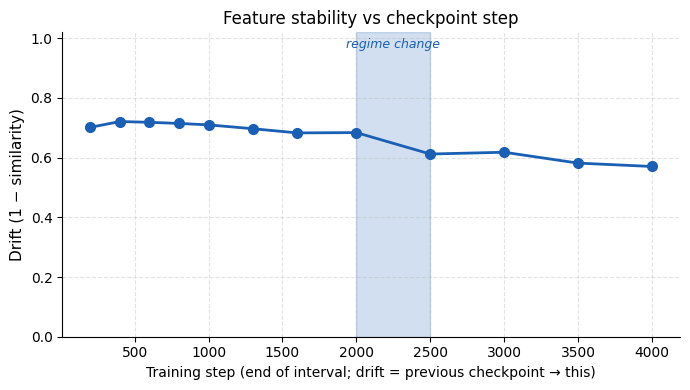

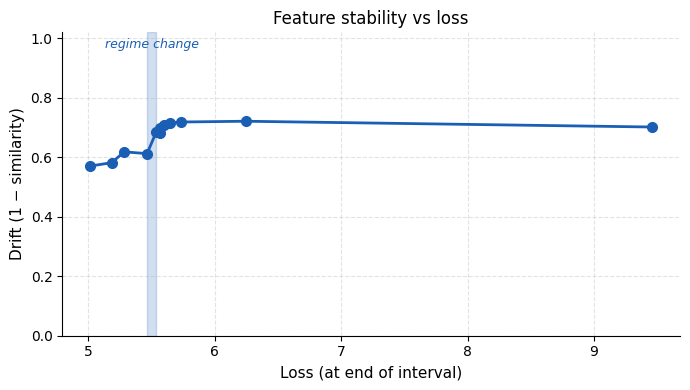

In [20]:
from plots import plot_stability_vs_step, plot_stability_vs_loss

stability_path = RESULTS_DIR / "stability_results.json"
if stability_path.exists():
    with open(stability_path) as f:
        stability = json.load(f)
    for r in stability:
        print(f"  {r['step_a']} -> {r['step_b']}: drift = {r['drift']:.4f}")
    plot_stability_vs_step(stability)
    loss_by_step = {}
    loss_path = RESULTS_DIR / "loss_history.json"
    if loss_path.exists():
        with open(loss_path) as f:
            loss_by_step = {x["step"]: x["loss"] for x in json.load(f)}
    plot_stability_vs_loss(stability, loss_by_step)
else:
    print("No stability_results.json yet. Run make sae-stability-all then make sae-plots.")

## Interpretation (H1/H2/H3)

Summarise what the drift curve suggests:
- **H1 (Gradual):** drift decreases smoothly over training.
- **H2 (Sharp):** drift drops abruptly after a critical loss/step (regime change).
- **H3 (Reorganization):** drift decreases early then flattens or rises; features form then reorganize.

In [21]:
stab_path = RESULTS_DIR / "stability_results.json"
if stab_path.exists():
    with open(stab_path) as f:
        stab = json.load(f)
    drifts = [r["drift"] for r in stab]
    print("Observed: drift (1 − similarity) between consecutive checkpoint pairs:")
    print(f"  values = {[round(d, 4) for d in drifts]}")
    if len(drifts) >= 2:
        trend = "decreasing" if drifts[-1] < drifts[0] else "increasing" if drifts[-1] > drifts[0] else "roughly flat"
        print(f"  trend = {trend}")
    print()
    print("Finding: Drift decreases over training, with a sharp drop after ~2000 steps (regime change), then a plateau.")
else:
    print("No stability_results.json. Run make sae-stability-all.")

Observed: drift (1 − similarity) between consecutive checkpoint pairs:
  values = [0.7017, 0.7211, 0.7185, 0.7147, 0.7099, 0.697, 0.683, 0.684, 0.6122, 0.6182, 0.5818, 0.5705]
  trend = decreasing

Finding: Drift decreases over training, with a sharp drop after ~2000 steps (regime change), then a plateau.


## Ablation (causal validation)

We ablate the **top-k** SAE feature contributions at a chosen step and measure ΔCE. If removing those features increases loss, they are **causal contributors**; the **random-k** control checks that the effect is specific to top-activated features.

In [22]:
ablation_path = RESULTS_DIR / "ablation_results.json"
if ablation_path.exists():
    with open(ablation_path) as f:
        abl = json.load(f)
    print(f"Step {abl['step']}, top_k={abl['top_k']}, n_batches={abl['n_batches']}")
    print(f"  CE (original): {abl['ce_original']}")
    print(f"  CE (ablated):  {abl['ce_ablated']}")
    print(f"  ΔCE (top-k):   {abl['delta_ce']}")
    if "delta_ce_random" in abl:
        print(f"  ΔCE (random-k): {abl['delta_ce_random']}")
    print()
    print("Interpretation:")
    if abl["delta_ce"] > 0.01:
        print("  → Top-k ablation increases loss: the SAE's top-activated features are causal contributors.")
    else:
        print("  → Top-k ablation has small effect; features may be weakly causal or try larger k / more batches.")
    if "delta_ce_random" in abl and abs(abl["delta_ce_random"]) < 0.01:
        print("  → Random-k ΔCE ≈ 0: the effect is specific to top features, not just removing any k dimensions.")
else:
    print("No ablation_results.json yet. Run make sae-ablation.")

Step 2000, top_k=5, n_batches=30
  CE (original): 5.531559
  CE (ablated):  5.618599
  ΔCE (top-k):   0.08704
  ΔCE (random-k): -8.4e-05

Interpretation:
  → Top-k ablation increases loss: the SAE's top-activated features are causal contributors.
  → Random-k ΔCE ≈ 0: the effect is specific to top features, not just removing any k dimensions.


## Max-activating examples (what do features mean?)

For a few SAE features at a chosen step, we show the **max-activating examples**: the token and preceding context where each feature fires most strongly. Data is synthetic (vocab 0–255 shown as bytes; non-printable as `.`). Run `make sae-max-activating STEP=4000` to generate `results/max_activating_results.json`.

**How to read it:** High activation + same token across examples → feature is a "token detector" (e.g. Feature 2 fires on comma `,`). Very low activations (e.g. 0.0000) → feature is sparse or dead; we're showing the least-zero examples.

In [23]:
max_act_path = RESULTS_DIR / "max_activating_results.json"
if max_act_path.exists():
    with open(max_act_path) as f:
        max_act = json.load(f)
    print(f"Step {max_act['step']}, n_batches={max_act['n_batches']}\n")
    for feat in max_act["features"]:
        print(f"Feature {feat['feature_idx']}:")
        for ex in feat["examples"]:
            print(f"  activation={ex['activation']:.4f}  token_id={ex['token_id']} '{ex['token_char']}'  context='{ex['context']}'")
        print()
else:
    print("No max_activating_results.json yet. Run: make sae-max-activating STEP=4000 --save")

Step 4000, n_batches=50

Feature 0:
  activation=0.0002  token_id=176 '.'  context='..#....)'
  activation=0.0001  token_id=205 '.'  context='[..) ..3'
  activation=0.0000  token_id=3 '.'  context='..'
  activation=0.0000  token_id=220 '.'  context='....'
  activation=0.0000  token_id=213 '.'  context=''

Feature 1:
  activation=0.0002  token_id=71 'G'  context='........'
  activation=0.0001  token_id=71 'G'  context='.c......'
  activation=0.0000  token_id=3 '.'  context='..'
  activation=0.0000  token_id=220 '.'  context='....'
  activation=0.0000  token_id=213 '.'  context=''

Feature 2:
  activation=3.1069  token_id=44 ','  context='.X<*..y.'
  activation=3.0761  token_id=44 ','  context='p'
  activation=3.0727  token_id=44 ','  context='.b..@...'
  activation=3.0545  token_id=44 ','  context='.......p'
  activation=3.0391  token_id=44 ','  context='.......'

Feature 3:
  activation=0.0000  token_id=3 '.'  context='..'
  activation=0.0000  token_id=220 '.'  context='....'
  activat

## Feature dynamics (interpretability over time)

We track **what** each feature fires on across steps (dominant token + consistency), not just direction drift. **Consistency** = fraction of top-20 max-activating positions with the same token_id (1.0 = clear token detector). A jump in consistency around the same step where drift plateaus (~2k) suggests a phase transition in interpretability. Generate data: `make sae-feature-dynamics`.

Dominant token and consistency per step (consistency = fraction of top-20 with same token_id)

Feature 0:
  step 1000: token_id=16 '.'  consistency=1.00  mean_act=1.9054
  step 2000: token_id=229 '.'  consistency=1.00  mean_act=0.7783
  step 3000: token_id=149 '.'  consistency=0.95  mean_act=1.8417
  step 4000: token_id=213 '.'  consistency=0.10  mean_act=0.0000

Feature 2:
  step 1000: token_id=248 '.'  consistency=1.00  mean_act=2.9344
  step 2000: token_id=213 '.'  consistency=0.10  mean_act=0.0000
  step 3000: token_id=71 'G'  consistency=0.10  mean_act=0.0005
  step 4000: token_id=44 ','  consistency=1.00  mean_act=2.9161

Feature 4:
  step 1000: token_id=213 '.'  consistency=0.10  mean_act=0.0000
  step 2000: token_id=95 '_'  consistency=0.45  mean_act=2.9143
  step 3000: token_id=213 '.'  consistency=0.10  mean_act=0.0000
  step 4000: token_id=0 '.'  consistency=0.95  mean_act=1.6402

Feature 5:
  step 1000: token_id=213 '.'  consistency=0.10  mean_act=0.0000
  step 2000: token_

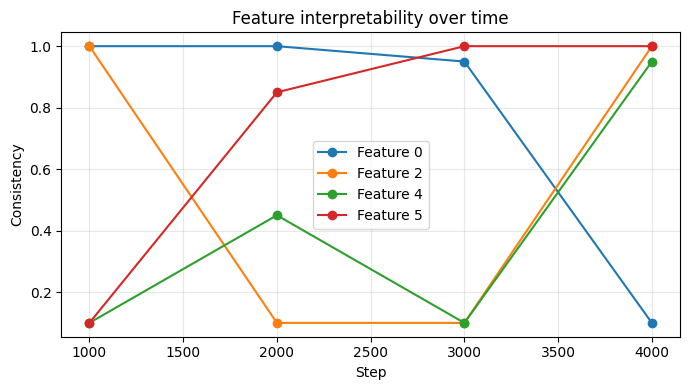

In [24]:
fd_path = RESULTS_DIR / "feature_dynamics.json"
if fd_path.exists():
    with open(fd_path) as f:
        fd = json.load(f)
    steps = fd["steps"]
    print("Dominant token and consistency per step (consistency = fraction of top-20 with same token_id)\n")
    for feat in fd["features"]:
        print(f"Feature {feat['feature_idx']}:")
        for step in steps:
            rec = feat["by_step"][str(step)]
            tid, char, cons, act = rec["dominant_token_id"], rec["dominant_char"], rec["consistency"], rec["mean_act"]
            print(f"  step {step}: token_id={tid} '{char}'  consistency={cons:.2f}  mean_act={act:.4f}")
        print()
    try:
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(figsize=(7, 4))
        for feat in fd["features"]:
            cons = [feat["by_step"][str(s)]["consistency"] for s in steps]
            ax.plot(steps, cons, "o-", label=f"Feature {feat['feature_idx']}")
        ax.set_xlabel("Step"); ax.set_ylabel("Consistency"); ax.set_title("Feature interpretability over time"); ax.legend(); ax.grid(True, alpha=0.3)
        plt.tight_layout(); plt.show()
    except Exception as e:
        print("(Plot skipped:", e, ")")
else:
    print("No feature_dynamics.json yet. Run: make sae-feature-dynamics")

## Summary: key findings

- **Stability:** Drift decreases over training with a regime change around ~2000 steps, then plateau; feature directions stabilize.
- **Causality:** Ablating top-5 features at step 2000 increases CE by ~0.09; random-k ablation ≈0 → effect is specific to top features.
- **Interpretability:** Max-activating examples show which token/context each feature fires on; feature dynamics show *when* one becomes a clear token detector (e.g. phase transition in interpretability).
- **Caveats:** One model size, one layer, one SAE config; synthetic data.

### Further experiments

- **More checkpoints:** Run SAE training and stability on a denser grid so drift vs step (and vs loss) can further clarify H1/H2/H3.
- **Ablation at multiple steps:** Run `make sae-ablation STEP=100`, then 400, 1000, 2000; plot ΔCE vs step to show *when* features become causal (e.g. only late in training).
- **Vary k:** Run ablation with `--top-k 1`, `5`, `10` to show that the causal effect scales with the number of top features removed.